In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [29]:
# Labels
labels = pd.read_csv("class.tsv",sep="\t",header=None,comment="#")

# Expression matrix
expr = pd.read_csv("filtered.tsv.gz",sep="\t",compression="gzip",comment="#")
expr.columns = expr.columns.str.strip()

# Columns mapping
columns = pd.read_csv("columns.tsv.gz",sep="\t",compression="gzip",comment="#")

In [33]:
x = expr["4404"]
y = expr["4359"]
labels.columns = ["Class"]

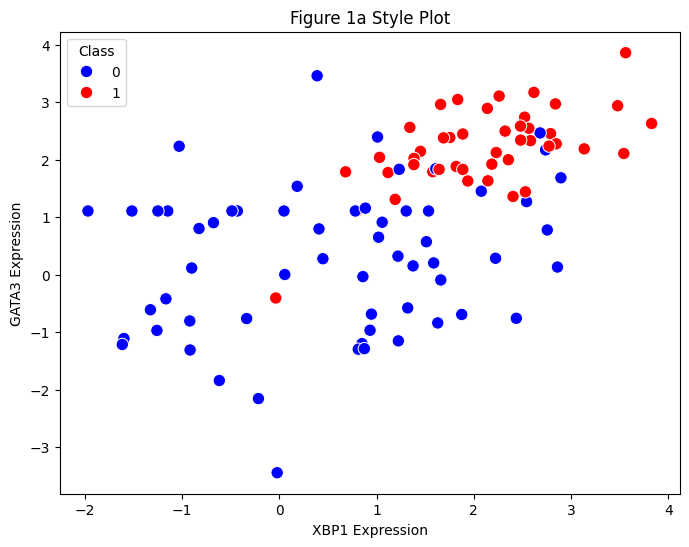

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = pd.DataFrame({"XBP1": x,"GATA3": y,"Class": labels["Class"]})
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df,x="XBP1",y="GATA3",hue="Class",palette={1:"red", 0:"blue"},s=80)

plt.xlabel("XBP1 Expression")
plt.ylabel("GATA3 Expression")
plt.title("Figure 1a Style Plot")
plt.show()

Explained Variance Ratio:
[0.77857624 0.22142376]


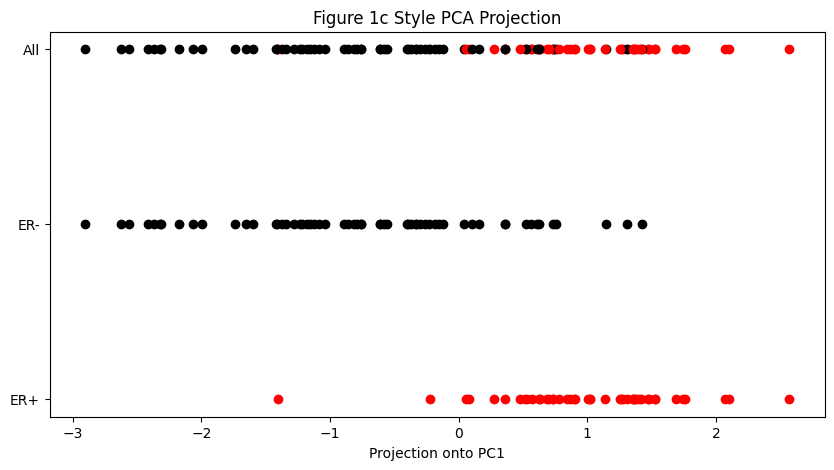

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Feature matrix
X = np.column_stack((x, y))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

pc1 = X_pca[:, 0]
plt.figure(figsize=(10,5))

# Plot all samples
for i in range(len(pc1)):
    color = "red" if labels["Class"][i] == 1 else "black"
    plt.scatter(pc1[i], 2, color=color)

# Plot only ER-
for i in range(len(pc1)):
    if labels["Class"][i] == 0:
        plt.scatter(pc1[i], 1, color="black")

# Plot only ER+
for i in range(len(pc1)):
    if labels["Class"][i] == 1:
        plt.scatter(pc1[i], 0, color="red")

# Labels
plt.yticks([2,1,0], ["All", "ER-", "ER+"])
plt.xlabel("Projection onto PC1")
plt.title("Figure 1c Style PCA Projection")
plt.show()